In [1]:
# NeuroGym W&B — LN vs noLN per architecture
from __future__ import annotations

import warnings
from statistics import mean, stdev

import matplotlib.pyplot as plt
import wandb

In [12]:
ENTITY = "royeyono"
PROJECT = "ng-delaymatchsample-v0"
PATH = f"{ENTITY}/{PROJECT}"

ARCHS = ("vanilla", "lstm")
LABELS = {"vanilla": "Vanilla RNN", "lstm": "LSTM"}
LN_LABELS = {True: "LayerNorm", False: "No LayerNorm"}
LN_COLORS = {True: "#1f77b4", False: "#ff7f0e"}
TOP_K = 5
PLOT_METRIC = "eval/trial_accuracy"
RANK_METRIC = "eval/trial_accuracy_auc"

print(PATH, f"top {TOP_K} by AUC → mean ± std")

royeyono/ng-delaymatchsample-v0 top 5 by AUC → mean ± std


In [13]:
def parse_run_name(name: str) -> tuple[str | None, bool | None]:
    """Return (arch, layer_norm) from batch run name ng_*_{tag}_*."""
    # Check ei_param_ln before ei (substring `_ei_` also matches `_ei_param_ln_`).
    if "_ei_param_ln_" in name:
        return "ei_param_ln", None
    if "_ei_" in name:
        return "ei", None
    if "_vanilla_ln_" in name:
        return "vanilla", True
    if "_vanilla_noln_" in name:
        return "vanilla", False
    if "_lstm_ln_" in name:
        return "lstm", True
    if "_lstm_noln_" in name:
        return "lstm", False
    return None, None


def run_meta(run: wandb.apis.public.Run) -> tuple[str | None, bool | None]:
    arch, ln = parse_run_name(run.name or "")
    if arch is not None:
        return arch, ln
    keys = list(run.config.keys())
    if not keys:
        return None, None
    cfg_arch = run.config.get("arch")
    if cfg_arch == "ei" and run.config.get("param_layer_norm"):
        return "ei_param_ln", None
    return cfg_arch, run.config.get("layer_norm")


def final_metric(run: wandb.apis.public.Run, key: str) -> float | None:
    v = run.summary.get(key)
    if v is not None:
        return float(v)
    last = None
    for row in run.history(keys=[key], pandas=False):
        if row.get(key) is not None:
            last = float(row[key])
    return last


def metric_series(run: wandb.apis.public.Run, key: str) -> list[tuple[int, float]]:
    pts = []
    for row in run.history(keys=[key, "_step"], pandas=False):
        if row.get(key) is not None:
            pts.append((int(row["_step"]), float(row[key])))
    pts.sort()
    return pts


def top_k_by_auc(runs: list[wandb.apis.public.Run], k: int) -> list[wandb.apis.public.Run]:
    scored = []
    for run in runs:
        score = final_metric(run, RANK_METRIC)
        if score is None:
            warnings.warn(f"skip {run.name}: no {RANK_METRIC}")
            continue
        scored.append((score, run))
    scored.sort(key=lambda x: (-x[0], x[1].id))
    return [run for _, run in scored[:k]]


def average_curve(runs: list[wandb.apis.public.Run], metric: str) -> tuple[list[int], list[float], list[float]]:
    """Per-step mean and std across runs."""
    by_step: dict[int, list[float]] = {}
    for run in runs:
        series = metric_series(run, metric)
        if not series:
            warnings.warn(f"skip {run.name}: no {metric}")
            continue
        for step, val in series:
            by_step.setdefault(step, []).append(val)
    steps = sorted(by_step)
    means, stds = [], []
    for step in steps:
        vals = by_step[step]
        means.append(mean(vals))
        stds.append(stdev(vals) if len(vals) > 1 else 0.0)
    return steps, means, stds

In [14]:
api = wandb.Api()
eligible = []
for r in api.runs(PATH):
    if r.state != "finished":
        continue
    arch, ln = run_meta(r)
    if arch in ARCHS and ln is not None:
        eligible.append(r)
if not eligible:
    raise ValueError(f"No eligible runs in {PATH!r}")

picked: dict[tuple[str, bool], list[wandb.apis.public.Run]] = {}
curves: dict[tuple[str, bool], tuple[list[int], list[float], list[float]]] = {}

for arch in ARCHS:
    for ln in (True, False):
        pool = [r for r in eligible if run_meta(r) == (arch, ln)]
        top = top_k_by_auc(pool, TOP_K)
        picked[(arch, ln)] = top
        curves[(arch, ln)] = average_curve(top, PLOT_METRIC)
        print(f"{LABELS[arch]} {LN_LABELS[ln]}: {len(top)}/{TOP_K} (pool {len(pool)})")

print(f"\n{'arch':<8} {'ln':<14} {'rank':<5} {'auc':>10}  run")
print("-" * 60)
for (arch, ln), group in picked.items():
    for rank, run in enumerate(group, 1):
        auc = final_metric(run, RANK_METRIC)
        print(f"{arch:<8} {LN_LABELS[ln]:<14} {rank:<5} {auc:>10.1f}  {run.name}")

Vanilla RNN LayerNorm: 5/5 (pool 10)
Vanilla RNN No LayerNorm: 5/5 (pool 10)
LSTM LayerNorm: 5/5 (pool 10)
LSTM No LayerNorm: 5/5 (pool 10)

arch     ln             rank         auc  run
------------------------------------------------------------
vanilla  LayerNorm      1         2507.3  ng_10310087_vanilla_ln_32
vanilla  LayerNorm      2         2497.6  ng_10310087_vanilla_ln_26
vanilla  LayerNorm      3         2496.2  ng_10310087_vanilla_ln_38
vanilla  LayerNorm      4         2494.9  ng_10310087_vanilla_ln_20
vanilla  LayerNorm      5         2494.9  ng_10310087_vanilla_ln_14
vanilla  No LayerNorm   1         2487.6  ng_10310087_vanilla_noln_51
vanilla  No LayerNorm   2         2485.2  ng_10310087_vanilla_noln_57
vanilla  No LayerNorm   3         2476.9  ng_10310087_vanilla_noln_39
vanilla  No LayerNorm   4         2476.6  ng_10310087_vanilla_noln_45
vanilla  No LayerNorm   5         2449.3  ng_10310087_vanilla_noln_33
lstm     LayerNorm      1         2505.7  ng_10310087_lstm_ln_

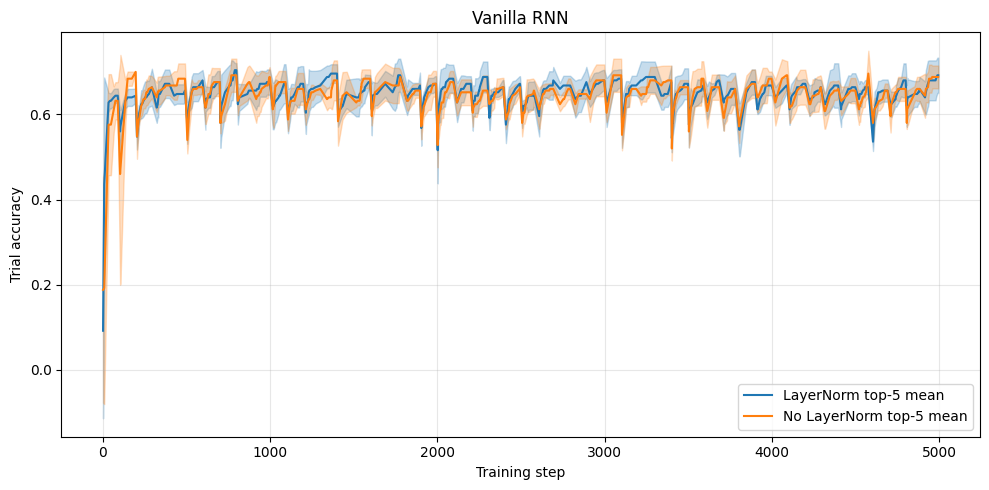

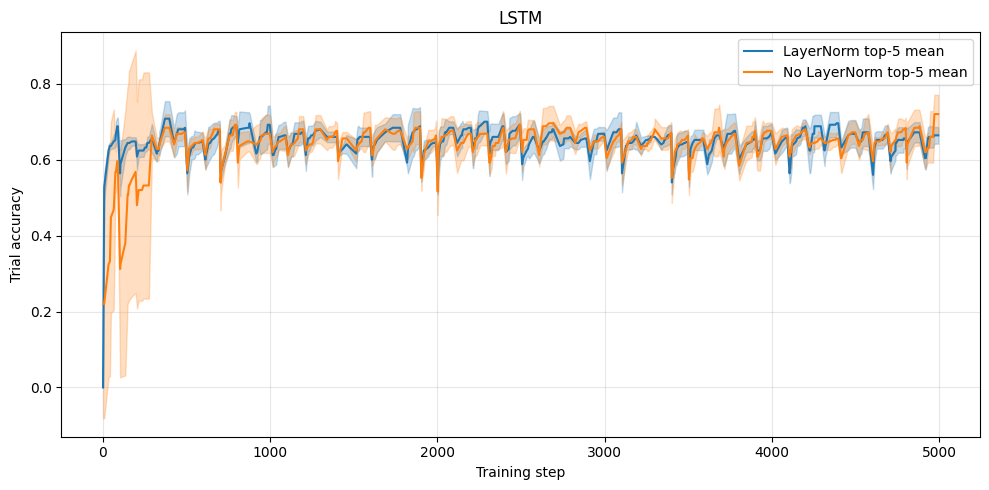

In [15]:
def plot_ln_comparison(arch: str) -> None:
    fig, ax = plt.subplots(figsize=(10, 5))
    for ln in (True, False):
        steps, means, stds = curves[(arch, ln)]
        if not steps:
            warnings.warn(f"no curve: {arch} {LN_LABELS[ln]}")
            continue
        color = LN_COLORS[ln]
        n = len(picked[(arch, ln)])
        ax.plot(steps, means, color=color, label=f"{LN_LABELS[ln]} top-{n} mean")
        ax.fill_between(
            steps,
            [m - s for m, s in zip(means, stds)],
            [m + s for m, s in zip(means, stds)],
            color=color,
            alpha=0.25,
        )
    ax.set(xlabel="Training step", ylabel="Trial accuracy", title=f"{LABELS[arch]}")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


plot_ln_comparison("vanilla")
plot_ln_comparison("lstm")

Selected EI runs: 5/5


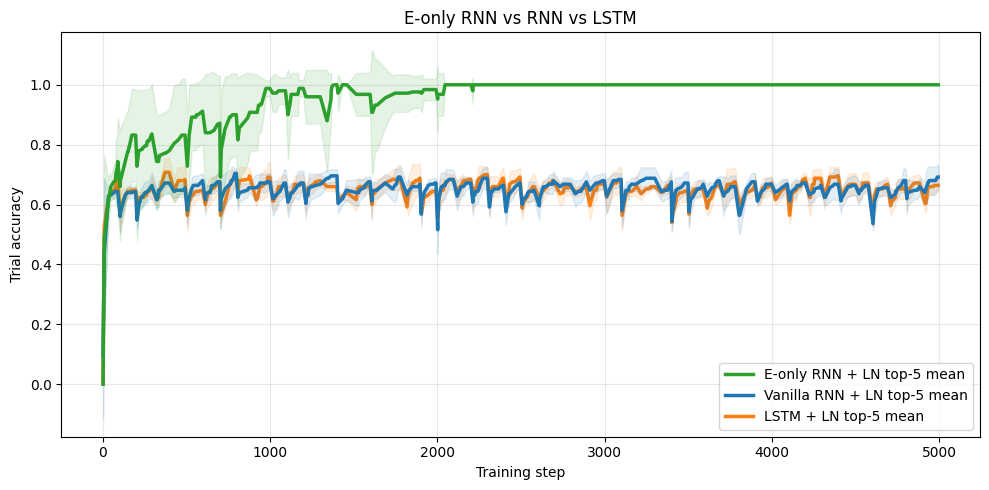


Top runs used (by AUC):

EI
  #1 auc=4908.4  ng_10310087_ei_36
  #2 auc=4674.3  ng_10310087_ei_42
  #3 auc=4568.8  ng_10310087_ei_24
  #4 auc=4290.2  ng_10310087_ei_54
  #5 auc=4164.7  ng_10310087_ei_30

Vanilla(RNN+LN)
  #1 auc=2507.3  ng_10310087_vanilla_ln_32
  #2 auc=2497.6  ng_10310087_vanilla_ln_26
  #3 auc=2496.2  ng_10310087_vanilla_ln_38
  #4 auc=2494.9  ng_10310087_vanilla_ln_20
  #5 auc=2494.9  ng_10310087_vanilla_ln_14

LSTM(LN)
  #1 auc=2505.7  ng_10310087_lstm_ln_40
  #2 auc=2503.0  ng_10310087_lstm_ln_46
  #3 auc=2497.2  ng_10310087_lstm_ln_34
  #4 auc=2494.9  ng_10310087_lstm_ln_28
  #5 auc=2494.4  ng_10310087_lstm_ln_52


In [16]:
# EI vs Vanilla(RNN+LN) vs LSTM(LN) — top TOP_K by AUC

def top_k_in_group(runs: list[wandb.apis.public.Run], arch: str, ln: bool | None) -> list[wandb.apis.public.Run]:
    pool = [r for r in runs if run_meta(r) == (arch, ln)]
    return top_k_by_auc(pool, TOP_K)


runs_all = [r for r in api.runs(PATH) if r.state == "finished"]

r_ei = top_k_in_group(runs_all, "ei", None)
r_vanilla_ln = top_k_in_group(runs_all, "vanilla", True)
r_lstm_ln = top_k_in_group(runs_all, "lstm", True)

print(f"Selected EI runs: {len(r_ei)}/{TOP_K}")

cur_ei = average_curve(r_ei, PLOT_METRIC)
cur_van = average_curve(r_vanilla_ln, PLOT_METRIC)
cur_lstm = average_curve(r_lstm_ln, PLOT_METRIC)

fig, ax = plt.subplots(figsize=(10, 5))

for label, color, z, picked_runs, (steps, means, stds) in (
    ("E-only RNN + LN", "#2ca02c", 3, r_ei, cur_ei),
    ("Vanilla RNN + LN", "#1f77b4", 2, r_vanilla_ln, cur_van),
    ("LSTM + LN", "#ff7f0e", 1, r_lstm_ln, cur_lstm),
):
    if not steps:
        warnings.warn(f"no curve for {label}")
        continue
    n = len(picked_runs)
    ax.fill_between(
        steps,
        [m - s for m, s in zip(means, stds)],
        [m + s for m, s in zip(means, stds)],
        color=color,
        alpha=0.12,
        zorder=z,
    )
    ax.plot(
        steps,
        means,
        color=color,
        linewidth=2.5,
        zorder=z + 0.1,
        label=f"{label} top-{n} mean",
    )

ax.set(
    xlabel="Training step",
    ylabel="Trial accuracy",
    title=f"E-only RNN vs RNN vs LSTM",
)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print("\nTop runs used (by AUC):")
for group_name, runs_group in (
    ("EI", r_ei),
    ("Vanilla(RNN+LN)", r_vanilla_ln),
    ("LSTM(LN)", r_lstm_ln),
):
    print(f"\n{group_name}")
    for i, r in enumerate(runs_group, 1):
        auc = final_metric(r, RANK_METRIC)
        print(f"  #{i} auc={auc:.1f}  {r.name}")

Selected E-only RNN + LN: 5/5
Selected E-only RNN + Param LN: 5/5


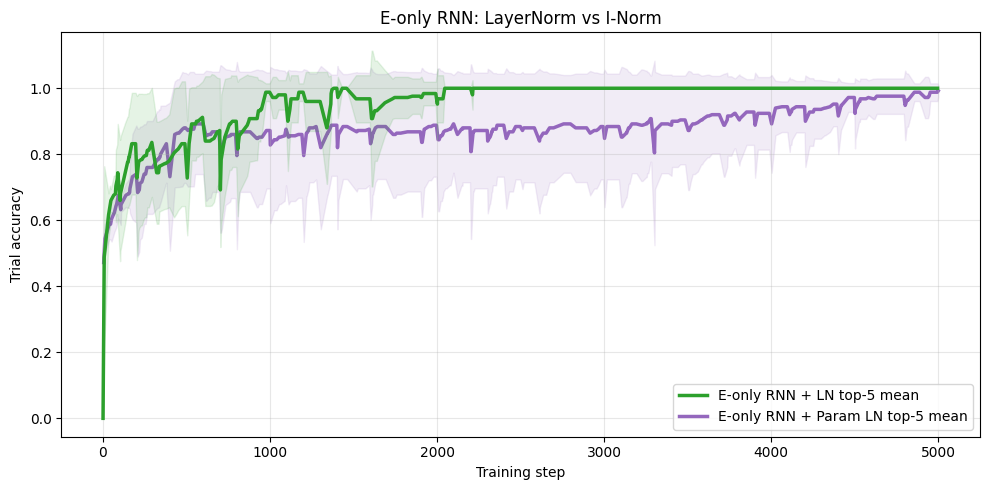


Top runs used (by AUC):

E-only RNN + LN
  #1 auc=4908.4  ng_10310087_ei_36
  #2 auc=4674.3  ng_10310087_ei_42
  #3 auc=4568.8  ng_10310087_ei_24
  #4 auc=4290.2  ng_10310087_ei_54
  #5 auc=4164.7  ng_10310087_ei_30

E-only RNN + Param LN
  #1 auc=4889.0  ng_10310087_ei_param_ln_37
  #2 auc=4831.1  ng_10310087_ei_param_ln_19
  #3 auc=4784.4  ng_10310087_ei_param_ln_25
  #4 auc=3104.8  ng_10310087_ei_param_ln_7
  #5 auc=2818.8  ng_10310087_ei_param_ln_13


In [17]:
# E-only RNN (LN) vs E-only RNN + Parametrized LN — top TOP_K by AUC

runs_ei_cmp = [r for r in api.runs(PATH) if r.state == "finished"]

r_ei_ln = top_k_in_group(runs_ei_cmp, "ei", None)
r_ei_param_ln = top_k_in_group(runs_ei_cmp, "ei_param_ln", None)

print(f"Selected E-only RNN + LN: {len(r_ei_ln)}/{TOP_K}")
print(f"Selected E-only RNN + Param LN: {len(r_ei_param_ln)}/{TOP_K}")

cur_ei_ln = average_curve(r_ei_ln, PLOT_METRIC)
cur_ei_param = average_curve(r_ei_param_ln, PLOT_METRIC)

fig, ax = plt.subplots(figsize=(10, 5))

for label, color, z, picked_runs, (steps, means, stds) in (
    ("E-only RNN + LN", "#2ca02c", 2, r_ei_ln, cur_ei_ln),
    ("E-only RNN + Param LN", "#9467bd", 1, r_ei_param_ln, cur_ei_param),
):
    if not steps:
        warnings.warn(f"no curve for {label}")
        continue
    n = len(picked_runs)
    ax.fill_between(
        steps,
        [m - s for m, s in zip(means, stds)],
        [m + s for m, s in zip(means, stds)],
        color=color,
        alpha=0.12,
        zorder=z,
    )
    ax.plot(
        steps,
        means,
        color=color,
        linewidth=2.5,
        zorder=z + 0.1,
        label=f"{label} top-{n} mean",
    )

ax.set(
    xlabel="Training step",
    ylabel="Trial accuracy",
    title="E-only RNN: LayerNorm vs I-Norm",
)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print("\nTop runs used (by AUC):")
for group_name, runs_group in (
    ("E-only RNN + LN", r_ei_ln),
    ("E-only RNN + Param LN", r_ei_param_ln),
):
    print(f"\n{group_name}")
    for i, r in enumerate(runs_group, 1):
        auc = final_metric(r, RANK_METRIC)
        print(f"  #{i} auc={auc:.1f}  {r.name}")


Aux curves over 5 Param LN runs:
  #1 auc=4889.0  ng_10310087_ei_param_ln_37
  #2 auc=4831.1  ng_10310087_ei_param_ln_19
  #3 auc=4784.4  ng_10310087_ei_param_ln_25
  #4 auc=3104.8  ng_10310087_ei_param_ln_7
  #5 auc=2818.8  ng_10310087_ei_param_ln_13


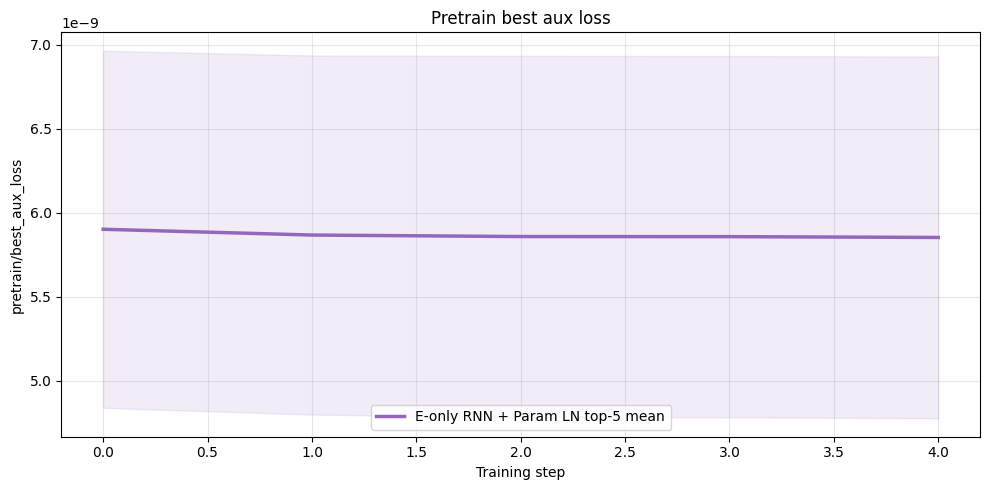

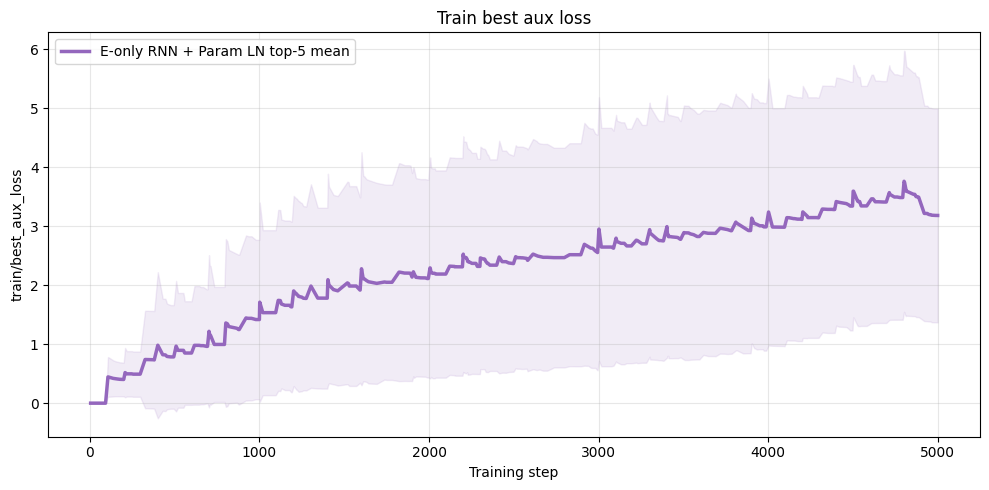

In [18]:
# Param LN aux losses — top TOP_K by AUC (reuse r_ei_param_ln from previous cell)

AUX_METRICS = (
    ("pretrain/best_aux_loss", "Pretrain best aux loss"),
    ("train/best_aux_loss", "Train best aux loss"),
)

if not r_ei_param_ln:
    warnings.warn("no ei_param_ln runs selected; skip aux-loss plots")
else:
    print(f"Aux curves over {len(r_ei_param_ln)} Param LN runs:")
    for i, r in enumerate(r_ei_param_ln, 1):
        auc = final_metric(r, RANK_METRIC)
        print(f"  #{i} auc={auc:.1f}  {r.name}")

    for metric, title in AUX_METRICS:
        steps, means, stds = average_curve(r_ei_param_ln, metric)
        fig, ax = plt.subplots(figsize=(10, 5))
        if not steps:
            warnings.warn(f"no curve for {metric}")
            ax.set(title=f"{title} (no data)")
        else:
            color = "#9467bd"
            ax.fill_between(
                steps,
                [m - s for m, s in zip(means, stds)],
                [m + s for m, s in zip(means, stds)],
                color=color,
                alpha=0.12,
            )
            ax.plot(
                steps,
                means,
                color=color,
                linewidth=2.5,
                label=f"E-only RNN + Param LN top-{len(r_ei_param_ln)} mean",
            )
            ax.set(
                xlabel="Training step",
                ylabel=metric,
                title=title,
            )
            ax.legend()
            ax.grid(alpha=0.3)
        fig.tight_layout()
        plt.show()


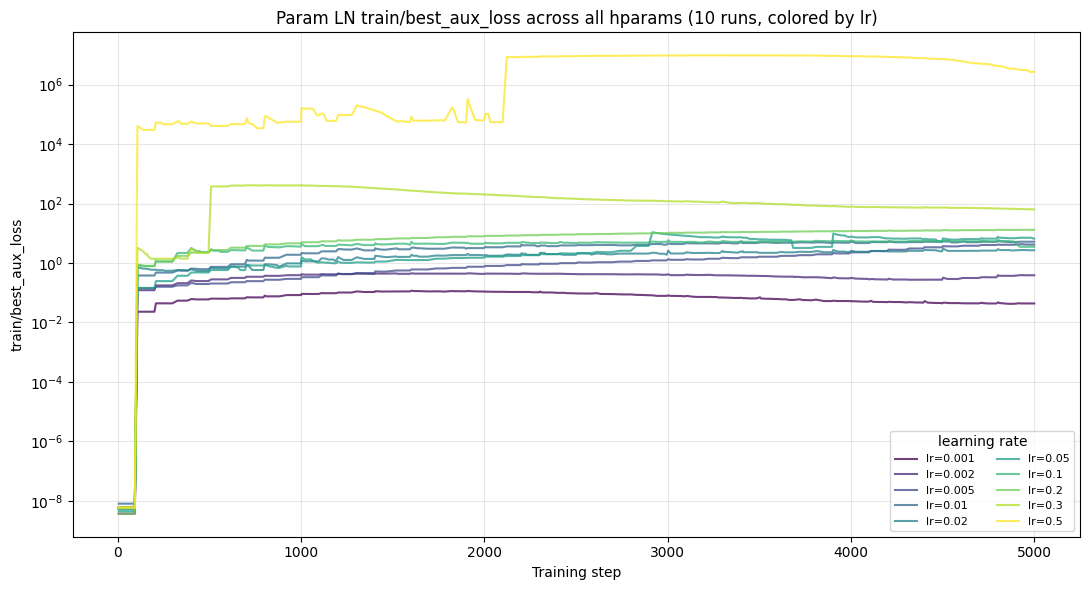

In [19]:
# Param LN train/best_aux_loss across ALL hparams (one curve per run, colored by lr)

AUX_METRIC = "train/best_aux_loss"


def _run_lr(run: wandb.apis.public.Run) -> float | None:
    lr = run.config.get("lr")
    return float(lr) if lr is not None else None


param_runs_all = []
for r in api.runs(PATH):
    if r.state != "finished":
        continue
    arch, _ = run_meta(r)
    if arch == "ei_param_ln":
        param_runs_all.append(r)

if not param_runs_all:
    warnings.warn("no ei_param_ln runs found; skip all-hparam aux plot")
else:
    uniq_lrs = sorted({lr for r in param_runs_all if (lr := _run_lr(r)) is not None})
    cmap = plt.get_cmap("viridis")
    lr_color = {
        lr: cmap(i / max(len(uniq_lrs) - 1, 1)) for i, lr in enumerate(uniq_lrs)
    }

    fig, ax = plt.subplots(figsize=(11, 6))
    plotted = 0
    all_positive = True
    seen_lr: set[float | None] = set()
    for r in sorted(param_runs_all, key=lambda x: (_run_lr(x) is None, _run_lr(x) or 0.0)):
        series = metric_series(r, AUX_METRIC)
        if not series:
            warnings.warn(f"skip {r.name}: no {AUX_METRIC}")
            continue
        steps = [s for s, _ in series]
        vals = [v for _, v in series]
        if any(v <= 0 for v in vals):
            all_positive = False
        lr = _run_lr(r)
        color = lr_color.get(lr, "gray")
        label = f"lr={lr:g}" if (lr is not None and lr not in seen_lr) else None
        seen_lr.add(lr)
        ax.plot(steps, vals, color=color, alpha=0.75, linewidth=1.5, label=label)
        plotted += 1

    ax.set(
        xlabel="Training step",
        ylabel=AUX_METRIC,
        title=f"Param LN {AUX_METRIC} across all hparams ({plotted} runs, colored by lr)",
    )
    # Aux loss is non-negative; log scale exposes the near-zero exact-init regime.
    if all_positive:
        ax.set_yscale("log")
    ax.grid(alpha=0.3, which="both")
    if uniq_lrs:
        ax.legend(title="learning rate", fontsize=8, ncol=2)
    fig.tight_layout()
    plt.show()

Matched (lr, seed) pairs: 10
  lr=0.001 seed=42  EI=2769.3  ParamLN=2426.6
  lr=0.002 seed=42  EI=2469.1  ParamLN=3104.8
  lr=0.005 seed=42  EI=2490.4  ParamLN=2818.8
  lr=0.01 seed=42  EI=3894.5  ParamLN=4831.1
  lr=0.02 seed=42  EI=4568.8  ParamLN=4784.4
  lr=0.05 seed=42  EI=4164.7  ParamLN=2814.5
  lr=0.1 seed=42  EI=4908.4  ParamLN=4889.0
  lr=0.2 seed=42  EI=4674.3  ParamLN=2492.2
  lr=0.3 seed=42  EI=2611.6  ParamLN=2505.9
  lr=0.5 seed=42  EI=4290.2  ParamLN=719.2


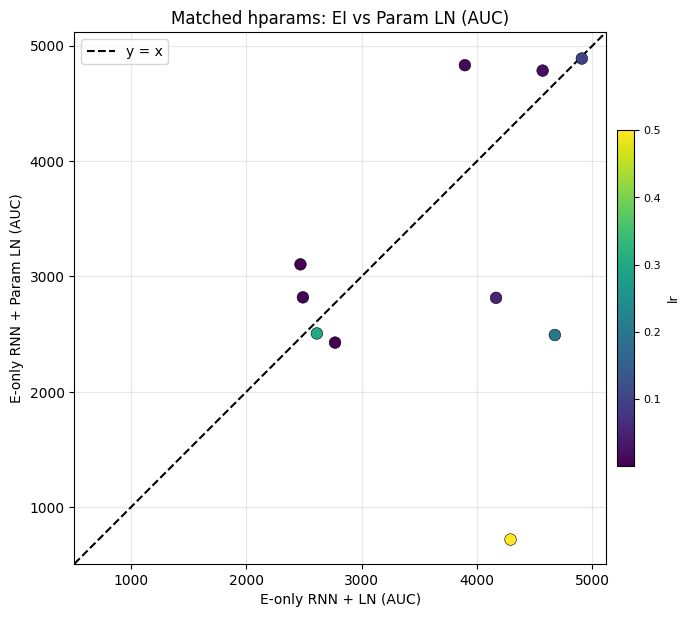

In [20]:
# Scatter: E-only RNN vs Param LN at matched (lr, seed) — sit on y=x?

def _run_lr_seed(run: wandb.apis.public.Run) -> tuple[float, int] | None:
    lr = run.config.get("lr")
    seed = run.config.get("seed")
    if lr is None or seed is None:
        return None
    return float(lr), int(seed)


runs_scatter = [r for r in api.runs(PATH) if r.state == "finished"]
ei_by_key: dict[tuple[float, int], wandb.apis.public.Run] = {}
param_by_key: dict[tuple[float, int], wandb.apis.public.Run] = {}

for r in runs_scatter:
    arch, _ = run_meta(r)
    key = _run_lr_seed(r)
    if key is None:
        continue
    if arch == "ei":
        ei_by_key[key] = r
    elif arch == "ei_param_ln":
        param_by_key[key] = r

pairs = []
for key in sorted(set(ei_by_key) & set(param_by_key)):
    r_ei = ei_by_key[key]
    r_pln = param_by_key[key]
    auc_ei = final_metric(r_ei, RANK_METRIC)
    auc_pln = final_metric(r_pln, RANK_METRIC)
    if auc_ei is None or auc_pln is None:
        warnings.warn(f"skip lr={key[0]} seed={key[1]}: missing {RANK_METRIC}")
        continue
    pairs.append((key[0], key[1], auc_ei, auc_pln, r_ei.name, r_pln.name))

print(f"Matched (lr, seed) pairs: {len(pairs)}")
for lr, seed, auc_ei, auc_pln, name_ei, name_pln in pairs:
    print(f"  lr={lr:g} seed={seed}  EI={auc_ei:.1f}  ParamLN={auc_pln:.1f}")

if not pairs:
    warnings.warn("no matched EI / Param LN pairs to scatter")
else:
    xs = [p[2] for p in pairs]  # EI AUC
    ys = [p[3] for p in pairs]  # Param LN AUC
    lrs = [p[0] for p in pairs]

    fig, ax = plt.subplots(figsize=(7, 7))
    sc = ax.scatter(xs, ys, c=lrs, cmap="viridis", s=70, zorder=3, edgecolors="k", linewidths=0.4)
    cbar = fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.02, shrink=0.7)
    cbar.set_label("lr", fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    lo = min(min(xs), min(ys))
    hi = max(max(xs), max(ys))
    pad = 0.05 * (hi - lo + 1e-9)
    lims = (lo - pad, hi + pad)
    ax.plot(lims, lims, "k--", linewidth=1.5, label="y = x", zorder=2)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal", adjustable="box")
    ax.set(
        xlabel="E-only RNN + LN (AUC)",
        ylabel="E-only RNN + Param LN (AUC)",
        title="Matched hparams: EI vs Param LN (AUC)",
    )
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


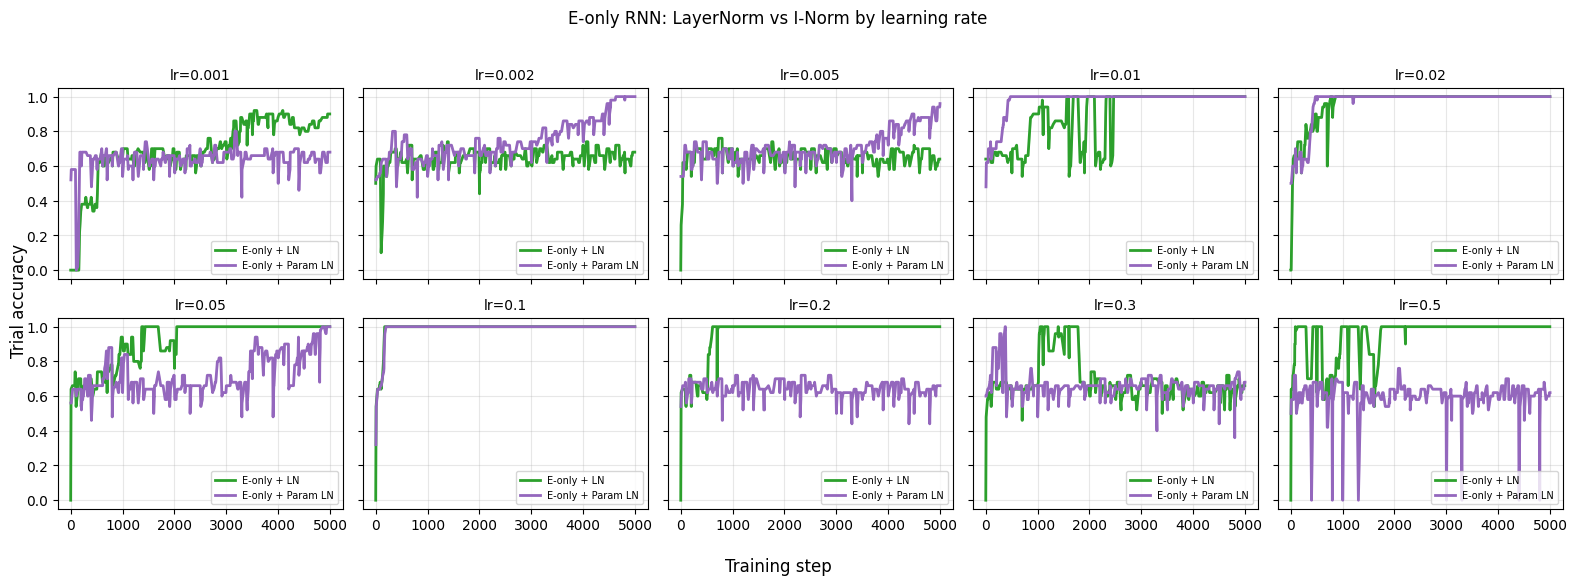

Runs per lr:
  lr=0.001:  LN=1  ParamLN=1
  lr=0.002:  LN=1  ParamLN=1
  lr=0.005:  LN=1  ParamLN=1
  lr=0.01:  LN=1  ParamLN=1
  lr=0.02:  LN=1  ParamLN=1
  lr=0.05:  LN=1  ParamLN=1
  lr=0.1:  LN=1  ParamLN=1
  lr=0.2:  LN=1  ParamLN=1
  lr=0.3:  LN=1  ParamLN=1
  lr=0.5:  LN=1  ParamLN=1


In [21]:
# Per-lr grid: E-only LN vs Param LN (mean ± std over seeds at that lr)
import math

def _run_lr(run: wandb.apis.public.Run) -> float | None:
    lr = run.config.get("lr")
    return float(lr) if lr is not None else None

runs_lr_grid = [r for r in api.runs(PATH) if r.state == "finished"]

by_lr: dict[float, dict[str, list]] = {}
for r in runs_lr_grid:
    arch, _ = run_meta(r)
    if arch not in {"ei", "ei_param_ln"}:
        continue
    lr = _run_lr(r)
    if lr is None:
        continue
    by_lr.setdefault(lr, {"ei": [], "ei_param_ln": []})[arch].append(r)

lrs = sorted(by_lr)
if not lrs:
    raise ValueError("No ei / ei_param_ln runs with config.lr found")

n = len(lrs)
ncols = min(5, n)
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(
    nrows, ncols, figsize=(3.2 * ncols, 2.8 * nrows), sharex=True, sharey=True, squeeze=False
)

series = (
    ("ei", "E-only + LN", "#2ca02c"),
    ("ei_param_ln", "E-only + Param LN", "#9467bd"),
)

for ax, lr in zip(axes.ravel(), lrs):
    for arch, label, color in series:
        pool = by_lr[lr][arch]
        steps, means, stds = average_curve(pool, PLOT_METRIC)
        if not steps:
            continue
        ax.fill_between(
            steps,
            [m - s for m, s in zip(means, stds)],
            [m + s for m, s in zip(means, stds)],
            color=color,
            alpha=0.15,
        )
        ax.plot(steps, means, color=color, linewidth=2.0, label=f"{label}")
    ax.set_title(f"lr={lr:g}", fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7, loc="lower right")

for ax in axes.ravel()[n:]:
    ax.set_visible(False)

fig.supxlabel("Training step")
fig.supylabel("Trial accuracy")
fig.suptitle("E-only RNN: LayerNorm vs I-Norm by learning rate", y=1.02)
fig.tight_layout()
plt.show()

print("Runs per lr:")
for lr in lrs:
    n_ei = len(by_lr[lr]["ei"])
    n_pln = len(by_lr[lr]["ei_param_ln"])
    print(f"  lr={lr:g}:  LN={n_ei}  ParamLN={n_pln}")
